# 00 — Data Exploration
> **Mục tiêu:** Khám phá sơ bộ cấu trúc dataset laptop. Chi tiết EDA và tiền xử lý sẽ được thực hiện ở các notebook tiếp theo.

| Thông tin | Chi tiết |
|---|---|
| Dataset | `clean_laptop_features.csv` |
| Nguồn | Web scraping các trang TMĐT Việt Nam |
| Mục tiêu dự đoán | Giá laptop (`shop_1_price`, `shop_2_price`, `shop_3_price`) |

## Table of Contents
1. [Setup & Load Data](#1-setup--load-data)
2. [Dataset Overview](#2-dataset-overview)
3. [Column Inventory](#3-column-inventory)
4. [Data Types](#4-data-types)
5. [Basic Statistics](#5-basic-statistics)
6. [Cardinality Check](#6-cardinality-check)
7. [Missing Values](#7-missing-values)
8. [Target Variable — Price](#8-target-variable--price)
9. [Quick Distribution — Categorical Features](#9-quick-distribution--categorical-features)
10. [Quick Distribution — Numerical Features](#10-quick-distribution--numerical-features)
11. [Summary & Next Steps](#11-summary--next-steps)

---
## 1. Setup & Load Data
Import thư viện và đọc dữ liệu từ file CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')

FILE_PATH = r"Y:\Python\Laptop-Price-Prediction\data\raw\clean_laptop_features.csv"

df = pd.read_csv(FILE_PATH)
print(f"Đọc dữ liệu thành công: {df.shape[0]:,} dòng × {df.shape[1]} cột")

Đọc dữ liệu thành công: 4,384 dòng × 43 cột


---
## 2. Dataset Overview
Kiểm tra kích thước tổng thể và xem thử vài dòng đầu.

In [2]:
print(f"Số dòng  : {df.shape[0]:,}")
print(f"Số cột   : {df.shape[1]}")
print(f"Bộ nhớ   : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Số dòng  : 4,384
Số cột   : 43
Bộ nhớ   : 9.70 MB


In [3]:
df.head()

,Hãng sản xuất,Hệ điều hành,Chất liệu vỏ,Công nghệ CPU,Loại CPU,Loại RAM,Dung lượng RAM,Tốc độ bus,Hỗ trợ RAM tối đa,Loại ổ cứng,Công nghệ màn hình,Kiểu card đồ họa,Công nghệ âm thanh,Cổng giao tiếp,Kết nối không dây,Webcam,Đèn bàn phím,Loại Pin,Dung lượng,source_url,shop_1_name,shop_1_price,shop_1_link,shop_2_name,shop_2_price,shop_2_link,shop_3_name,shop_3_price,shop_3_link,Khe thẻ nhớ,Tính năng khác,Dung lượng VGA,Dung lượng ổ cứng (GB),Độ phân giải ngang (px),Độ phân giải dọc (px),Kích thước (inch),Trọng lượng (kg),Tốc độ CPU (GHz),Tốc độ tối đa (GHz),Chiều dài (mm),Chiều rộng (mm),Độ dày (mm),Đồ họa đã làm sạch
0,Acer,Windows 10 Home,Nhôm,Intel Core i5,8265U,DDR4,8.00,2666 MHz,20 GB,SSD,"IPS, Acer ComfyView LCD",Card tích hợp,Realtek High Definition,"2x USB 3.1, 1x USB 3.1 Type-C, 1x USB 2.0, HDM...",Wifi 6 AX201 Bluetooth v5.0,HD Webcam,Có,Pin liền,3 cell,https://websosanh.vn/laptop-acer-aspire-a514-5...,baochau.vn,14950000,https://baochau.vn/laptop-acer-aspire-a514-53-...,quangmai.net,15950000,https://quangmai.net/san-pham/laptop-acer-aspi...,compro.com.vn,"15,990,000.00",http://compro.com.vn/laptop-acer-aspire-5-a514...,NaN,Unknown,NaN,512.00,"1,920.00","1,080.00",14.00,1.50,1.00,3.60,328.80,236.00,17.95,Intel UHD Graphics
1,Lg,Windows 10 Home,Hợp kim,Intel Core i7,1165G7,LPDDR4x,16.00,4266 MHz,NaN,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card tích hợp,DTS X:Ultra Audio,"2 x Thunderbolt 4 USB-C, 2 x USB 3.2, HDMI","Bluetooth 5.1, Wi-Fi 6 (802.11ax)",HD Webcam,Có,NaN,2 cell,https://websosanh.vn/laptop-lg-gram-17z90p-gah...,tiki.vn,32640000,https://fast.accesstrade.com.vn/deep_link/4348...,tinhocsangtao.vn,47500000,https://tinhocsangtao.vn/san-pham/laptop-lg-gr...,mixicomputer.vn,"35,190,000.00",https://mixicomputer.vn/laptop-lg-gram-17z90p-...,Micro SD,"Bảo mật vân tay, Tiêu chuẩn Nền Intel Evo",NaN,512.00,"2,560.00","1,600.00",17.00,1.35,2.80,4.70,380.20,260.10,17.80,Intel Iris Xe
2,Lenovo,Windows 11 Home,NaN,AMD Ryzen 7,8845HS,DDR5,16.00,5600 MHz,32 GB,SSD,"Tấm nền IPS, Chống chói Anti-Glare, 350 nits",Card rời,Nahimic Audio,"USB-A, USB-C, HDMI 2.1","Wifi 802.11ax, Bluetooth 5.3",Full HD Webcam,Có,NaN,4 cell,https://websosanh.vn/laptop-lenovo-gaming-legi...,congnghesgsaigon.com,30900000,https://congnghesgsaigon.com/laptop-lenovo-leg...,tnc.com.vn,31490000,https://www.tnc.com.vn/laptop-lenovo-legion-sl...,tymo.vn,"33,490,000.00",https://tymo.vn/san-pham/laptop-lenovo-legion-...,SD,Bảo mật vân tay,8 GB,512.00,"2,560.00","1,600.00",16.00,2.30,3.80,5.10,359.70,260.50,19.90,RTX 4060
3,Lenovo,Windows 11 Home,NaN,AMD Ryzen 7,7840H,LPDDR5,16.00,5600 MHz,NaN,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card rời,Unknown,"2 x USB-A 3.2 Gen 2, 1 x USB-C 3.2 Gen 2, HDMI...","Wifi 802.11ax, Bluetooth 5.2",Full HD Webcam,Có,NaN,4 cell,https://websosanh.vn/laptop-lenovo-legion-5-r7...,redlaptop.vn,23900000,https://redlaptop.vn/laptop-lenovo-legion-5-r7...,laptopk1.vn,23990000,https://laptopk1.vn/lenovo-legion-5-r7000-aph9...,laptoptcc.com,"24,900,000.00",https://laptoptcc.com/lenovo-legion-5-r7000-ap...,SD,Unknown,8 GB,512.00,"1,920.00","1,080.00",15.60,2.40,3.80,5.10,NaN,NaN,NaN,RTX4060
4,Msi,Windows 11 Home,Kim loại,Intel Core Ultra 7,255HX,DDR5,16.00,6400 MHz,96 GB,SSD,"240Hz, 100% DCI-P3, IPS-level panel",Card rời,Hi-Res Audio,2 x Thunderbolt 5\r\n2 x Type-A USB3.2 Gen2\r\...,"Wi-Fi 7 (802.11be), Bluetooth 5.4",IR + Full HD Webcam,Có,NaN,4 cell,https://websosanh.vn/laptop-msi-vector-16-hx-a...,dienmayxanh.com,54790000,https://fast.accesstrade.com.vn/deep_link/4348...,cellphones.com.vn,62990000,https://fast.accesstrade.com.vn/deep_link/4348...,fptshop.com.vn,"62,990,000.00",https://gotrackecom.info/v0/PNH7aNSG4goF2ti0s0...,SD,Unknown,12 GB,512.00,"2,560.00","1,600.00",16.00,2.70,1.80,5.20,357.00,284.00,22.50,RTX 5070


In [4]:
df.tail()

,Hãng sản xuất,Hệ điều hành,Chất liệu vỏ,Công nghệ CPU,Loại CPU,Loại RAM,Dung lượng RAM,Tốc độ bus,Hỗ trợ RAM tối đa,Loại ổ cứng,Công nghệ màn hình,Kiểu card đồ họa,Công nghệ âm thanh,Cổng giao tiếp,Kết nối không dây,Webcam,Đèn bàn phím,Loại Pin,Dung lượng,source_url,shop_1_name,shop_1_price,shop_1_link,shop_2_name,shop_2_price,shop_2_link,shop_3_name,shop_3_price,shop_3_link,Khe thẻ nhớ,Tính năng khác,Dung lượng VGA,Dung lượng ổ cứng (GB),Độ phân giải ngang (px),Độ phân giải dọc (px),Kích thước (inch),Trọng lượng (kg),Tốc độ CPU (GHz),Tốc độ tối đa (GHz),Chiều dài (mm),Chiều rộng (mm),Độ dày (mm),Đồ họa đã làm sạch
4379,Lenovo,Windows 11 Home,NaN,Intel Core Ultra 7,255H,DDR5,16.00,5600 MHz,64 GB,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card tích hợp,Dolby Atmos,"USB-A, USB-C, HDMI 2.1","Wi-Fi 7 (802.11be), Bluetooth 5.4",IR + 5MP Webcam,Có,NaN,3 cell,https://websosanh.vn/laptop-lenovo-thinkpad-l1...,vitinhmanhphat.com,31350000,https://vitinhmanhphat.com/lenovo-thinkpad-l14...,tnc.com.vn,31490000,https://www.tnc.com.vn/laptop-lenovo-thinkpad-...,eaz.com.vn,"33,999,000.00",https://eaz.com.vn/Laptop-Lenovo-ThinkPad-L14-...,NaN,Unknown,NaN,512.00,"1,920.00","1,200.00",14.00,1.38,NaN,5.10,313.70,226.00,22.90,Other GPU
4380,Hp,Windows 11 Home,Kim loại,AMD Ryzen 5,8640HS,LPDDR5,16.00,6400 MHz,NaN,SSD,"OLED, multitouch-enabled, 48-120 Hz, 0.2 ms re...",Card tích hợp,Poly Studio; Dual speakers; DTS:X Ultra; HP Au...,2 x USB Type-C\r\n2 x USB Type-A\r\n1 x HDMI 2...,"Wi-Fi 6E, Bluetooth 5.3",5MP IR camera,Có đèn bàn phím,Pin liền,3 cell,https://websosanh.vn/laptop-hp-envy-x360-14-fa...,cellphones.com.vn,22690000,https://fast.accesstrade.com.vn/deep_link/4348...,hungphuc.vn,28200000,https://www.hungphuc.vn/laptop-hp/laptop-hp-en...,tymo.vn,"24,490,000.00",https://tymo.vn/san-pham/laptop-hp-envy-x360-1...,NaN,Unknown,NaN,"1,024.00","2,880.00","1,800.00",14.00,1.39,3.50,4.90,313.30,218.90,16.90,AMD Radeon Graphics
4381,Lenovo,Windows 10,NaN,Intel Core i7,9750H,DDR4,16.00,2666 MHz,NaN,HDD,"FHD IPS - Non-Glare, 300 nits, 144Hz G-sync",Card rời + Card tích hợp,Unknown,"1x Mini DisplayPort 1.4, 1x HDMI 2.0, 1x Ether...",Bluetooth v4.1,Unknown,Unknown,Pin rời,3 cell,https://websosanh.vn/laptop-lenovo-legion-y740...,smart24h.vn,39800000,http://smart24h.vn/lenovo-legion-y740-15ichg-8...,compro.com.vn,47590000,http://compro.com.vn/may-tinh-xach-tay-laptop-...,nnkk.vn,"49,390,000.00",https://www.nnkk.vn/laptop-lenovo-legion-y740-...,"D, SDHC, SDXC, MMC",Unknown,6 GB,"1,024.00","1,920.00","1,080.00",15.60,2.40,2.60,4.50,NaN,NaN,NaN,RTX2060
4382,Hp,Windows 10 Home,Nhựa,Intel Core i5,1135G7,DDR4,8.00,3200 MHz,NaN,SSD,"IPS, narrow bezel, anti-glare, 250 nits, 45% NTSC",Card tích hợp,Unknown,"1 x Type-C USB 3.1 Gen 1 (Power Delivery, Disp...","Bluetooth 5.0, Wi-Fi 802.11 a/b/g/n/ac",Có,Unknown,NaN,3 cell,https://websosanh.vn/laptop-hp-probook-430-g8-...,svcvietnam.com.vn,21090000,https://svcvietnam.com.vn/laptop-hp-probook-43...,smnet.vn,21186000,https://smnet.vn/san-pham/laptop-hp-probook-43...,mayina0.com,"21,200,000.00",https://mayina0.com/hp/laptop/laptop-hp-proboo...,"SD, SDXC, SDHC",Nhận dạng vân tay,NaN,512.00,NaN,NaN,13.30,1.28,2.40,4.20,306.90,208.40,15.90,Intel Iris Xe
4383,Hp,Windows 11 Pro,NaN,Intel Core Ultra 7,155H,LPDDR5x,32.00,7500 MHz,NaN,SSD,"Cảm ứng, Công nghệ IPS, Anti-glare, Độ sáng 40...",Card tích hợp,Poly Studio,1 x Cổng USB Type-C\r\n1 x Cổng HDMI 2.1\r\n1 ...,"Wi-Fi 6E, Bluetooth 5.3",5 MP IR camera,Unknown,Pin liền,6 cell,https://websosanh.vn/laptop-hp-elitebook-x360-...,ben.com.vn,63019000,https://fast.accesstrade.com.vn/deep_link/4348...,tnc.com.vn,31490000,https://www.tnc.com.vn/laptop-hp-elitebook-x36...,laptopworld.vn,"54,290,000.00",https://laptopworld.vn/laptop-hp-elitebook-x36...,NaN,Bảo mật vân tay,NaN,"1,024.00","1,920.00","1,200.00",14.00,1.38,1.40,4.80,NaN,NaN,NaN,Intel Arc Graphics


In [5]:
df.sample(5, random_state=42)

,Hãng sản xuất,Hệ điều hành,Chất liệu vỏ,Công nghệ CPU,Loại CPU,Loại RAM,Dung lượng RAM,Tốc độ bus,Hỗ trợ RAM tối đa,Loại ổ cứng,Công nghệ màn hình,Kiểu card đồ họa,Công nghệ âm thanh,Cổng giao tiếp,Kết nối không dây,Webcam,Đèn bàn phím,Loại Pin,Dung lượng,source_url,shop_1_name,shop_1_price,shop_1_link,shop_2_name,shop_2_price,shop_2_link,shop_3_name,shop_3_price,shop_3_link,Khe thẻ nhớ,Tính năng khác,Dung lượng VGA,Dung lượng ổ cứng (GB),Độ phân giải ngang (px),Độ phân giải dọc (px),Kích thước (inch),Trọng lượng (kg),Tốc độ CPU (GHz),Tốc độ tối đa (GHz),Chiều dài (mm),Chiều rộng (mm),Độ dày (mm),Đồ họa đã làm sạch
670,Lenovo,Windows 11 Home,NaN,Intel Core Ultra 5,225H,LPDDR5x,32.00,8400 MHz,NaN,SSD,"IPS 500nits Anti-glare, 100% sRGB, 60Hz, Low P...",Card tích hợp,Dolby Atmos,"USB-A, USB-C, HDMI 2.1","Wi-Fi 7 (802.11be), Bluetooth 5.4",IR + Full HD Webcam,Unknown,NaN,3 cell,https://websosanh.vn/laptop-lenovo-thinkpad-x1...,hkc.vn,44500000,https://hkc.vn/san-pham/laptop-lenovo-thinkpad...,dienmayxanh.com,49290000,https://fast.accesstrade.com.vn/deep_link/4348...,tnc.com.vn,"31,490,000.00",https://www.tnc.com.vn/laptop-lenovo-thinkpad-...,NaN,TPM 2.0,NaN,"1,024.00","1,920.00","1,200.00",14.00,1.01,NaN,4.90,312.80,214.75,8.38,Intel Arc Graphics
2417,Dell,Windows 10 Home,NaN,Intel Core i7,10510U,DDR4,8.00,2666 MHz,NaN,SSD,NaN,Card rời,Unknown,"USB 2.0, HDMI, USB 3.1 Gen 1 Type-C, USB 3.1 G...","802.11 a/b/g/n/ac, 10/100/1000 GbE, Bluetooth 4.2",Có,Unknown,NaN,3 cell,https://websosanh.vn/laptop-dell-vostro-v5590a...,sondat.vn,21590000,https://sondat.vn/notebook-dell-vostro-v5590a-...,mayvanphongonline.com,22150000,http://mayvanphongonline.com/san-pham/laptop-d...,maytinhdongvan.com,"22,500,000.00",https://maytinhdongvan.com/san-pham/dell-vostr...,"SD, SDHC, SDXC",Unknown,2 GB,256.00,"1,920.00","1,080.00",15.60,1.66,1.80,4.90,NaN,NaN,NaN,Unknown
596,Lenovo,Windows 11 Home,NaN,Intel Core i7,13700H,DDR4,16.00,3200 MHz,48 GB,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card tích hợp,Unknown,"1 x USB 2.0, 1 x USB 3.2 Gen 1, HDMI 2.1","Wifi 802.11ax, Bluetooth 5.1",IR + Full HD Webcam,Unknown,NaN,3 cell,https://websosanh.vn/laptop-lenovo-thinkpad-e1...,hungphuc.vn,22190000,https://www.hungphuc.vn/laptop-lenovo/laptop-l...,eaz.com.vn,22399000,https://eaz.com.vn/Lenovo-Thinkpad-E16-Gen-1-(...,maytinhcdc.vn,"22,409,000.00",https://maytinhcdc.vn/laptop-lenovo-thinkpad-e...,NaN,Bảo mật vân tay,NaN,512.00,"1,920.00","1,200.00",16.00,1.81,2.40,5.00,NaN,NaN,NaN,Intel Iris Xe
2629,Lenovo,Windows 11 Home,NaN,Intel core Ultra 7,155H,LPDDR5x,32.00,6400 MHz,NaN,SSD,"OLED, 400nits",Card tích hợp,Dolby Audio,"USB-A, USB-C, HDMI 2.1","Wifi 802.11ax, Bluetooth 5.2",IR + Full HD Webcam,Có,NaN,3 cell,https://websosanh.vn/laptop-lenovo-ideapad-sli...,hoanghamobile.com,25690000,https://fast.accesstrade.com.vn/deep_link/4348...,dienmayxanh.com,25990000,https://fast.accesstrade.com.vn/deep_link/4348...,ben.com.vn,"30,019,000.00",https://fast.accesstrade.com.vn/deep_link/4348...,Micro SD,Unknown,NaN,512.00,"1,920.00","1,200.00",14.00,1.46,1.40,4.80,312.00,221.00,16.90,Intel Arc Graphics
1395,Asus,Windows 11 Home,NaN,AMD Ryzen 5,7535HS,DDR5,8.00,5600 MHz,32 GB,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card rời,DTS software,"1 x Thunderbolt 4, 1 x USB 3.2 Gen 2 Type-C, 2...","Wifi 802.11ax, Bluetooth 5.3",HD Webcam,Có,NaN,3 cell,https://websosanh.vn/laptop-asus-tuf-gaming-a1...,eaz.com.vn,16399000,https://eaz.com.vn/Laptop-ASUS-TUF-Gaming-A15-...,hugotech.vn,16990000,https://hugotech.vn/laptop-asus-tuf-gaming-a15...,laptopaz.vn,"16,990,000.00",https://laptopaz.vn/new-100-asus-tuf-gaming-a1...,NaN,Unknown,4 GB,512.00,"1,920.00","1,080.00",15.60,2.30,3.30,4.55,359.00,256.00,22.80,RTX 3050


---
## 3. Column Inventory
Liệt kê toàn bộ cột, phân loại sơ bộ theo nhóm chức năng.

In [6]:
print("Toàn bộ cột trong dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

Toàn bộ cột trong dataset:
   1. Hãng sản xuất
   2. Hệ điều hành
   3. Chất liệu vỏ
   4. Công nghệ CPU
   5. Loại CPU
   6. Loại RAM
   7. Dung lượng RAM
   8. Tốc độ bus
   9. Hỗ trợ RAM tối đa
  10. Loại ổ cứng
  11. Công nghệ màn hình
  12. Kiểu card đồ họa
  13. Công nghệ âm thanh
  14. Cổng giao tiếp
  15. Kết nối không dây
  16. Webcam
  17. Đèn bàn phím
  18. Loại Pin
  19. Dung lượng
  20. source_url
  21. shop_1_name
  22. shop_1_price
  23. shop_1_link
  24. shop_2_name
  25. shop_2_price
  26. shop_2_link
  27. shop_3_name
  28. shop_3_price
  29. shop_3_link
  30. Khe thẻ nhớ
  31. Tính năng khác
  32. Dung lượng VGA
  33. Dung lượng ổ cứng (GB)
  34. Độ phân giải ngang (px)
  35. Độ phân giải dọc (px)
  36. Kích thước (inch)
  37. Trọng lượng (kg)
  38. Tốc độ CPU (GHz)
  39. Tốc độ tối đa (GHz)
  40. Chiều dài (mm)
  41. Chiều rộng (mm)
  42. Độ dày (mm)
  43. Đồ họa đã làm sạch


In [7]:
# Phân nhóm cột theo chức năng
col_groups = {
    'Thông tin chung': ['Hãng sản xuất', 'Hệ điều hành', 'Chất liệu vỏ'],
    'CPU': ['Công nghệ CPU', 'Loại CPU', 'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)'],
    'RAM': ['Loại RAM', 'Dung lượng RAM', 'Tốc độ bus', 'Hỗ trợ RAM tối đa'],
    'Lưu trữ': ['Loại ổ cứng', 'Dung lượng ổ cứng (GB)', 'Dung lượng'],
    'Màn hình': ['Công nghệ màn hình', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)', 'Kích thước (inch)'],
    'Đồ họa': ['Kiểu card đồ họa', 'Dung lượng VGA', 'Đồ họa đã làm sạch'],
    'Kết nối & I/O': ['Cổng giao tiếp', 'Kết nối không dây', 'Khe thẻ nhớ', 'Webcam'],
    'Thiết kế vật lý': ['Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)', 'Trọng lượng (kg)'],
    'Pin & Âm thanh': ['Loại Pin', 'Công nghệ âm thanh', 'Đèn bàn phím'],
    'Giá & Shop': ['shop_1_name', 'shop_1_price', 'shop_2_name', 'shop_2_price', 'shop_3_name', 'shop_3_price'],
    'Metadata': ['source_url', 'shop_1_link', 'shop_2_link', 'shop_3_link', 'Tính năng khác'],
}

for group, cols in col_groups.items():
    exist = [c for c in cols if c in df.columns]
    print(f"[{group}] ({len(exist)} cột): {exist}")

[Thông tin chung] (3 cột): ['Hãng sản xuất', 'Hệ điều hành', 'Chất liệu vỏ']
[CPU] (4 cột): ['Công nghệ CPU', 'Loại CPU', 'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)']
[RAM] (4 cột): ['Loại RAM', 'Dung lượng RAM', 'Tốc độ bus', 'Hỗ trợ RAM tối đa']
[Lưu trữ] (3 cột): ['Loại ổ cứng', 'Dung lượng ổ cứng (GB)', 'Dung lượng']
[Màn hình] (4 cột): ['Công nghệ màn hình', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)', 'Kích thước (inch)']
[Đồ họa] (3 cột): ['Kiểu card đồ họa', 'Dung lượng VGA', 'Đồ họa đã làm sạch']
[Kết nối & I/O] (4 cột): ['Cổng giao tiếp', 'Kết nối không dây', 'Khe thẻ nhớ', 'Webcam']
[Thiết kế vật lý] (4 cột): ['Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)', 'Trọng lượng (kg)']
[Pin & Âm thanh] (3 cột): ['Loại Pin', 'Công nghệ âm thanh', 'Đèn bàn phím']
[Giá & Shop] (6 cột): ['shop_1_name', 'shop_1_price', 'shop_2_name', 'shop_2_price', 'shop_3_name', 'shop_3_price']
[Metadata] (5 cột): ['source_url', 'shop_1_link', 'shop_2_link', 'shop_3_link', 'Tính năng khác']


---
## 4. Data Types
Kiểm tra kiểu dữ liệu từng cột và đếm theo nhóm.

In [8]:
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(1)
})
dtype_df

,Column,Dtype,Non-Null Count,Null Count,Null %
0,Hãng sản xuất,object,4204,180,4.10
1,Hệ điều hành,object,4384,0,0.00
2,Chất liệu vỏ,object,2169,2215,50.50
3,Công nghệ CPU,object,4290,94,2.10
4,Loại CPU,object,4315,69,1.60
5,Loại RAM,object,4066,318,7.30
6,Dung lượng RAM,float64,4363,21,0.50
7,Tốc độ bus,object,3877,507,11.60
8,Hỗ trợ RAM tối đa,object,1910,2474,56.40
9,Loại ổ cứng,object,4165,219,5.00


In [9]:
print("Tóm tắt kiểu dữ liệu:")
print(df.dtypes.value_counts())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f"\nCột dạng chuỗi (object): {len(cat_cols)}")
print(f"Cột dạng số (numeric)  : {len(num_cols)}")

Tóm tắt kiểu dữ liệu:
object     29
float64    12
int64       2
Name: count, dtype: int64

Cột dạng chuỗi (object): 29
Cột dạng số (numeric)  : 14


---
## 5. Basic Statistics
Thống kê mô tả cho các cột số và cột phân loại.

In [10]:
print("Thống kê mô tả — Cột số:")
df[num_cols].describe().T

Thống kê mô tả — Cột số:


,count,mean,std,min,25%,50%,75%,max
Dung lượng RAM,"4,363.00",16.07,85.74,2.00,8.00,16.00,16.00,"5,600.00"
shop_1_price,"4,384.00","25,577,849.31","21,545,632.28","3,400,000.00","14,587,500.00","20,690,000.00","30,912,500.00","860,000,000.00"
shop_2_price,"4,384.00","25,963,812.74","17,400,372.13","3,000,000.00","15,087,500.00","21,250,000.00","30,999,250.00","179,400,000.00"
shop_3_price,"4,382.00","27,778,761.84","51,093,729.85","3,498,000.00","15,500,000.00","21,699,000.00","31,490,000.00","2,750,000,000.00"
Dung lượng ổ cứng (GB),"4,159.00",647.92,432.22,16.00,512.00,512.00,"1,024.00","8,192.00"
Độ phân giải ngang (px),"4,064.00","2,071.08",447.61,920.00,"1,920.00","1,920.00","1,920.00","3,840.00"
Độ phân giải dọc (px),"4,064.00","1,227.21",314.42,108.00,"1,080.00","1,080.00","1,200.00","2,400.00"
Kích thước (inch),"4,373.00",21.34,46.63,2.14,14.00,15.60,15.60,398.00
Trọng lượng (kg),"4,237.00",2.15,18.34,0.00,1.40,1.65,1.99,"1,112.00"
Tốc độ CPU (GHz),"3,749.00",2.51,8.62,0.90,1.70,2.20,2.60,400.00


In [11]:
print("Thống kê mô tả — Cột phân loại:")
df[cat_cols].describe().T

Thống kê mô tả — Cột phân loại:


,count,unique,top,freq
Hãng sản xuất,4204,24,Hp,832
Hệ điều hành,4384,63,Windows 11 Home,2491
Chất liệu vỏ,2169,44,Nhựa,1023
Công nghệ CPU,4290,126,Intel Core i5,1281
Loại CPU,4315,390,1135G7,235
Loại RAM,4066,29,DDR4,2112
Tốc độ bus,3877,45,3200 MHz,1232
Hỗ trợ RAM tối đa,1910,23,32 GB,641
Loại ổ cứng,4165,9,SSD,3697
Công nghệ màn hình,4147,1426,"Tấm nền IPS, Chống chói Anti-Glare",572


---
## 6. Cardinality Check
Kiểm tra số lượng giá trị duy nhất từng cột — giúp phân biệt cột high-cardinality (cần xử lý đặc biệt) vs low-cardinality.

In [12]:
cardinality = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Dtype': df.dtypes.values
}).sort_values('Unique Values', ascending=False).reset_index(drop=True)

cardinality

,Column,Unique Values,Dtype
0,source_url,4384,object
1,shop_3_link,4381,object
2,shop_2_link,4381,object
3,shop_1_link,4379,object
4,Cổng giao tiếp,2751,object
5,shop_1_price,1902,int64
6,shop_2_price,1821,int64
7,shop_3_price,1763,float64
8,Công nghệ màn hình,1426,object
9,Kết nối không dây,671,object


In [13]:
HIGH_CARD_THRESHOLD = 100

high_card = cardinality[cardinality['Unique Values'] >= HIGH_CARD_THRESHOLD]
low_card  = cardinality[cardinality['Unique Values'] <  HIGH_CARD_THRESHOLD]

print(f"High-cardinality (>= {HIGH_CARD_THRESHOLD} unique): {len(high_card)} cột")
print(high_card['Column'].tolist())

print(f"\nLow-cardinality  (< {HIGH_CARD_THRESHOLD} unique): {len(low_card)} cột")
print(low_card['Column'].tolist())

High-cardinality (>= 100 unique): 22 cột
['source_url', 'shop_3_link', 'shop_2_link', 'shop_1_link', 'Cổng giao tiếp', 'shop_1_price', 'shop_2_price', 'shop_3_price', 'Công nghệ màn hình', 'Kết nối không dây', 'shop_3_name', 'shop_2_name', 'Chiều rộng (mm)', 'shop_1_name', 'Chiều dài (mm)', 'Độ dày (mm)', 'Loại CPU', 'Công nghệ âm thanh', 'Trọng lượng (kg)', 'Tính năng khác', 'Webcam', 'Công nghệ CPU']

Low-cardinality  (< 100 unique): 21 cột
['Đồ họa đã làm sạch', 'Kích thước (inch)', 'Khe thẻ nhớ', 'Hệ điều hành', 'Đèn bàn phím', 'Tốc độ bus', 'Chất liệu vỏ', 'Tốc độ tối đa (GHz)', 'Tốc độ CPU (GHz)', 'Loại RAM', 'Độ phân giải dọc (px)', 'Độ phân giải ngang (px)', 'Dung lượng ổ cứng (GB)', 'Kiểu card đồ họa', 'Hãng sản xuất', 'Hỗ trợ RAM tối đa', 'Dung lượng RAM', 'Dung lượng VGA', 'Dung lượng', 'Loại ổ cứng', 'Loại Pin']


---
## 7. Missing Values
Tổng hợp và trực quan hoá tỷ lệ missing value toàn dataset.

In [14]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False).reset_index(drop=True)

print(f"Tổng số cột có missing: {len(missing)} / {df.shape[1]}")
missing

Tổng số cột có missing: 30 / 43


,Column,Missing Count,Missing %
0,Loại Pin,3036,69.25
1,Dung lượng VGA,2916,66.51
2,Hỗ trợ RAM tối đa,2474,56.43
3,Chất liệu vỏ,2215,50.52
4,Khe thẻ nhớ,2156,49.18
5,Dung lượng,650,14.83
6,Tốc độ CPU (GHz),635,14.48
7,Tốc độ bus,507,11.56
8,Độ dày (mm),456,10.40
9,Chiều dài (mm),456,10.40


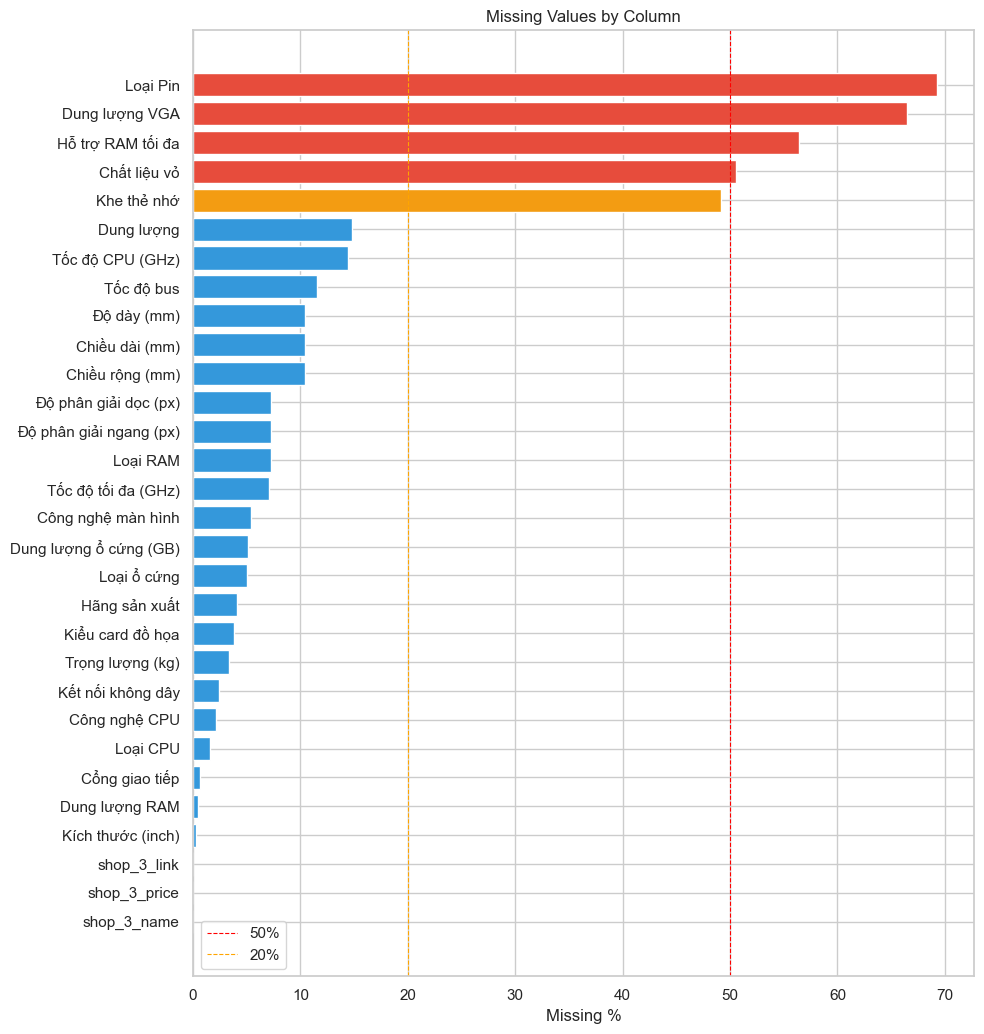

In [15]:
fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.35)))

colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#3498db'
          for v in missing['Missing %']]

ax.barh(missing['Column'], missing['Missing %'], color=colors)
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
ax.axvline(20, color='orange', linestyle='--', linewidth=0.8, label='20%')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Target Variable — Price
Phân tích biến mục tiêu: giá từ 3 shop. Kiểm tra phân phối, outlier và tương quan giữa các cột giá.

In [16]:
price_cols = ['shop_1_price', 'shop_2_price', 'shop_3_price']

print("Thống kê cơ bản — Giá (VNĐ):")
df[price_cols].describe().applymap(lambda x: f"{x:,.0f}")

Thống kê cơ bản — Giá (VNĐ):


,shop_1_price,shop_2_price,shop_3_price
count,"4,384","4,384","4,382"
mean,"25,577,849","25,963,813","27,778,762"
std,"21,545,632","17,400,372","51,093,730"
min,"3,400,000","3,000,000","3,498,000"
25%,"14,587,500","15,087,500","15,500,000"
50%,"20,690,000","21,250,000","21,699,000"
75%,"30,912,500","30,999,250","31,490,000"
max,"860,000,000","179,400,000","2,750,000,000"


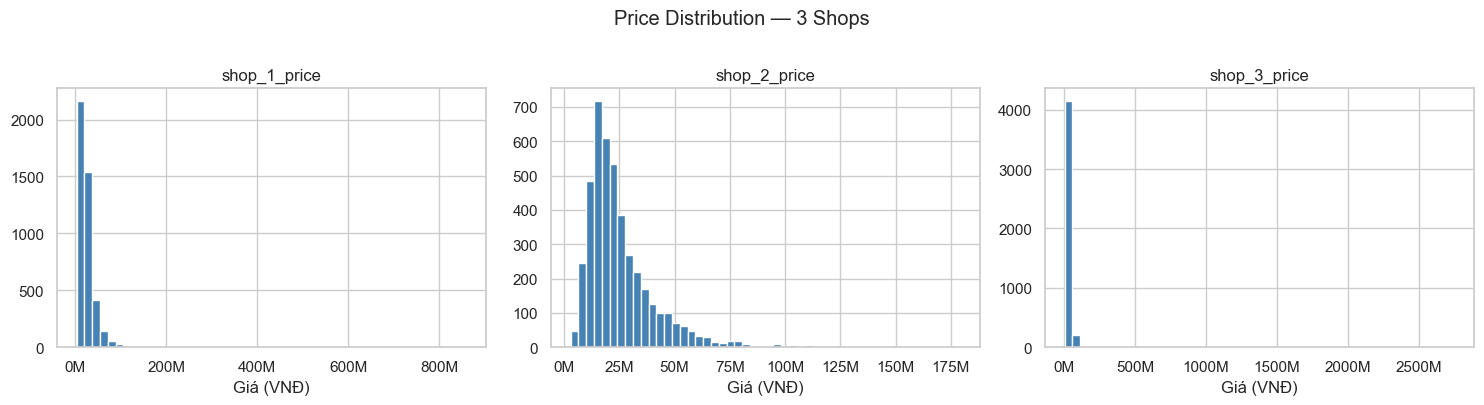

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, price_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Giá (VNĐ)')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Price Distribution — 3 Shops', y=1.01)
plt.tight_layout()
plt.show()

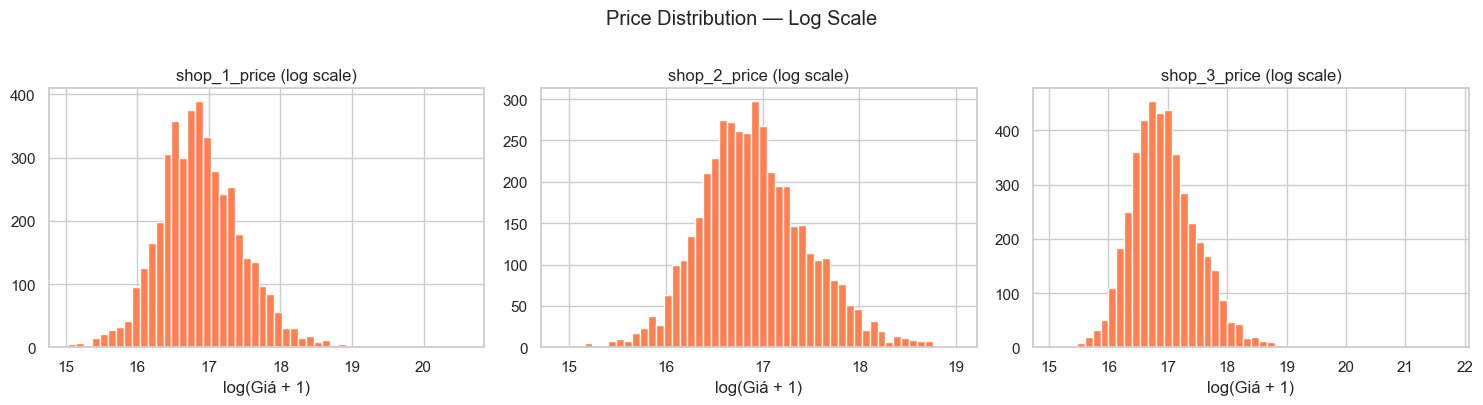

In [18]:
# Phân phối log-scale (kiểm tra tính skewed)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, price_cols):
    data = np.log1p(df[col].dropna())
    ax.hist(data, bins=50, color='coral', edgecolor='white')
    ax.set_title(f'{col} (log scale)')
    ax.set_xlabel('log(Giá + 1)')

plt.suptitle('Price Distribution — Log Scale', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Tương quan giữa các cột giá
price_data = df[price_cols].dropna()
print(f"Số dòng có đủ 3 giá: {len(price_data):,}")
print("\nMa trận tương quan:")
print(price_data.corr().round(3))

Số dòng có đủ 3 giá: 4,382

Ma trận tương quan:
              shop_1_price  shop_2_price  shop_3_price
shop_1_price          1.00          0.78          0.28
shop_2_price          0.78          1.00          0.35
shop_3_price          0.28          0.35          1.00


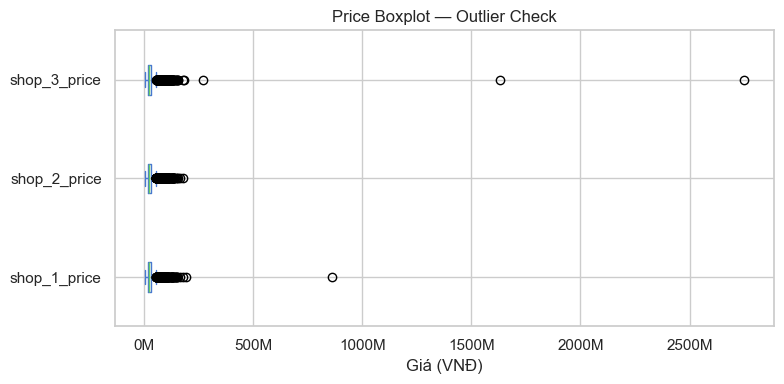

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
df[price_cols].plot(kind='box', ax=ax, vert=False)
ax.set_xlabel('Giá (VNĐ)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Price Boxplot — Outlier Check')
plt.tight_layout()
plt.show()

---
## 9. Quick Distribution — Categorical Features
Xem top giá trị của các cột phân loại low-cardinality quan trọng.

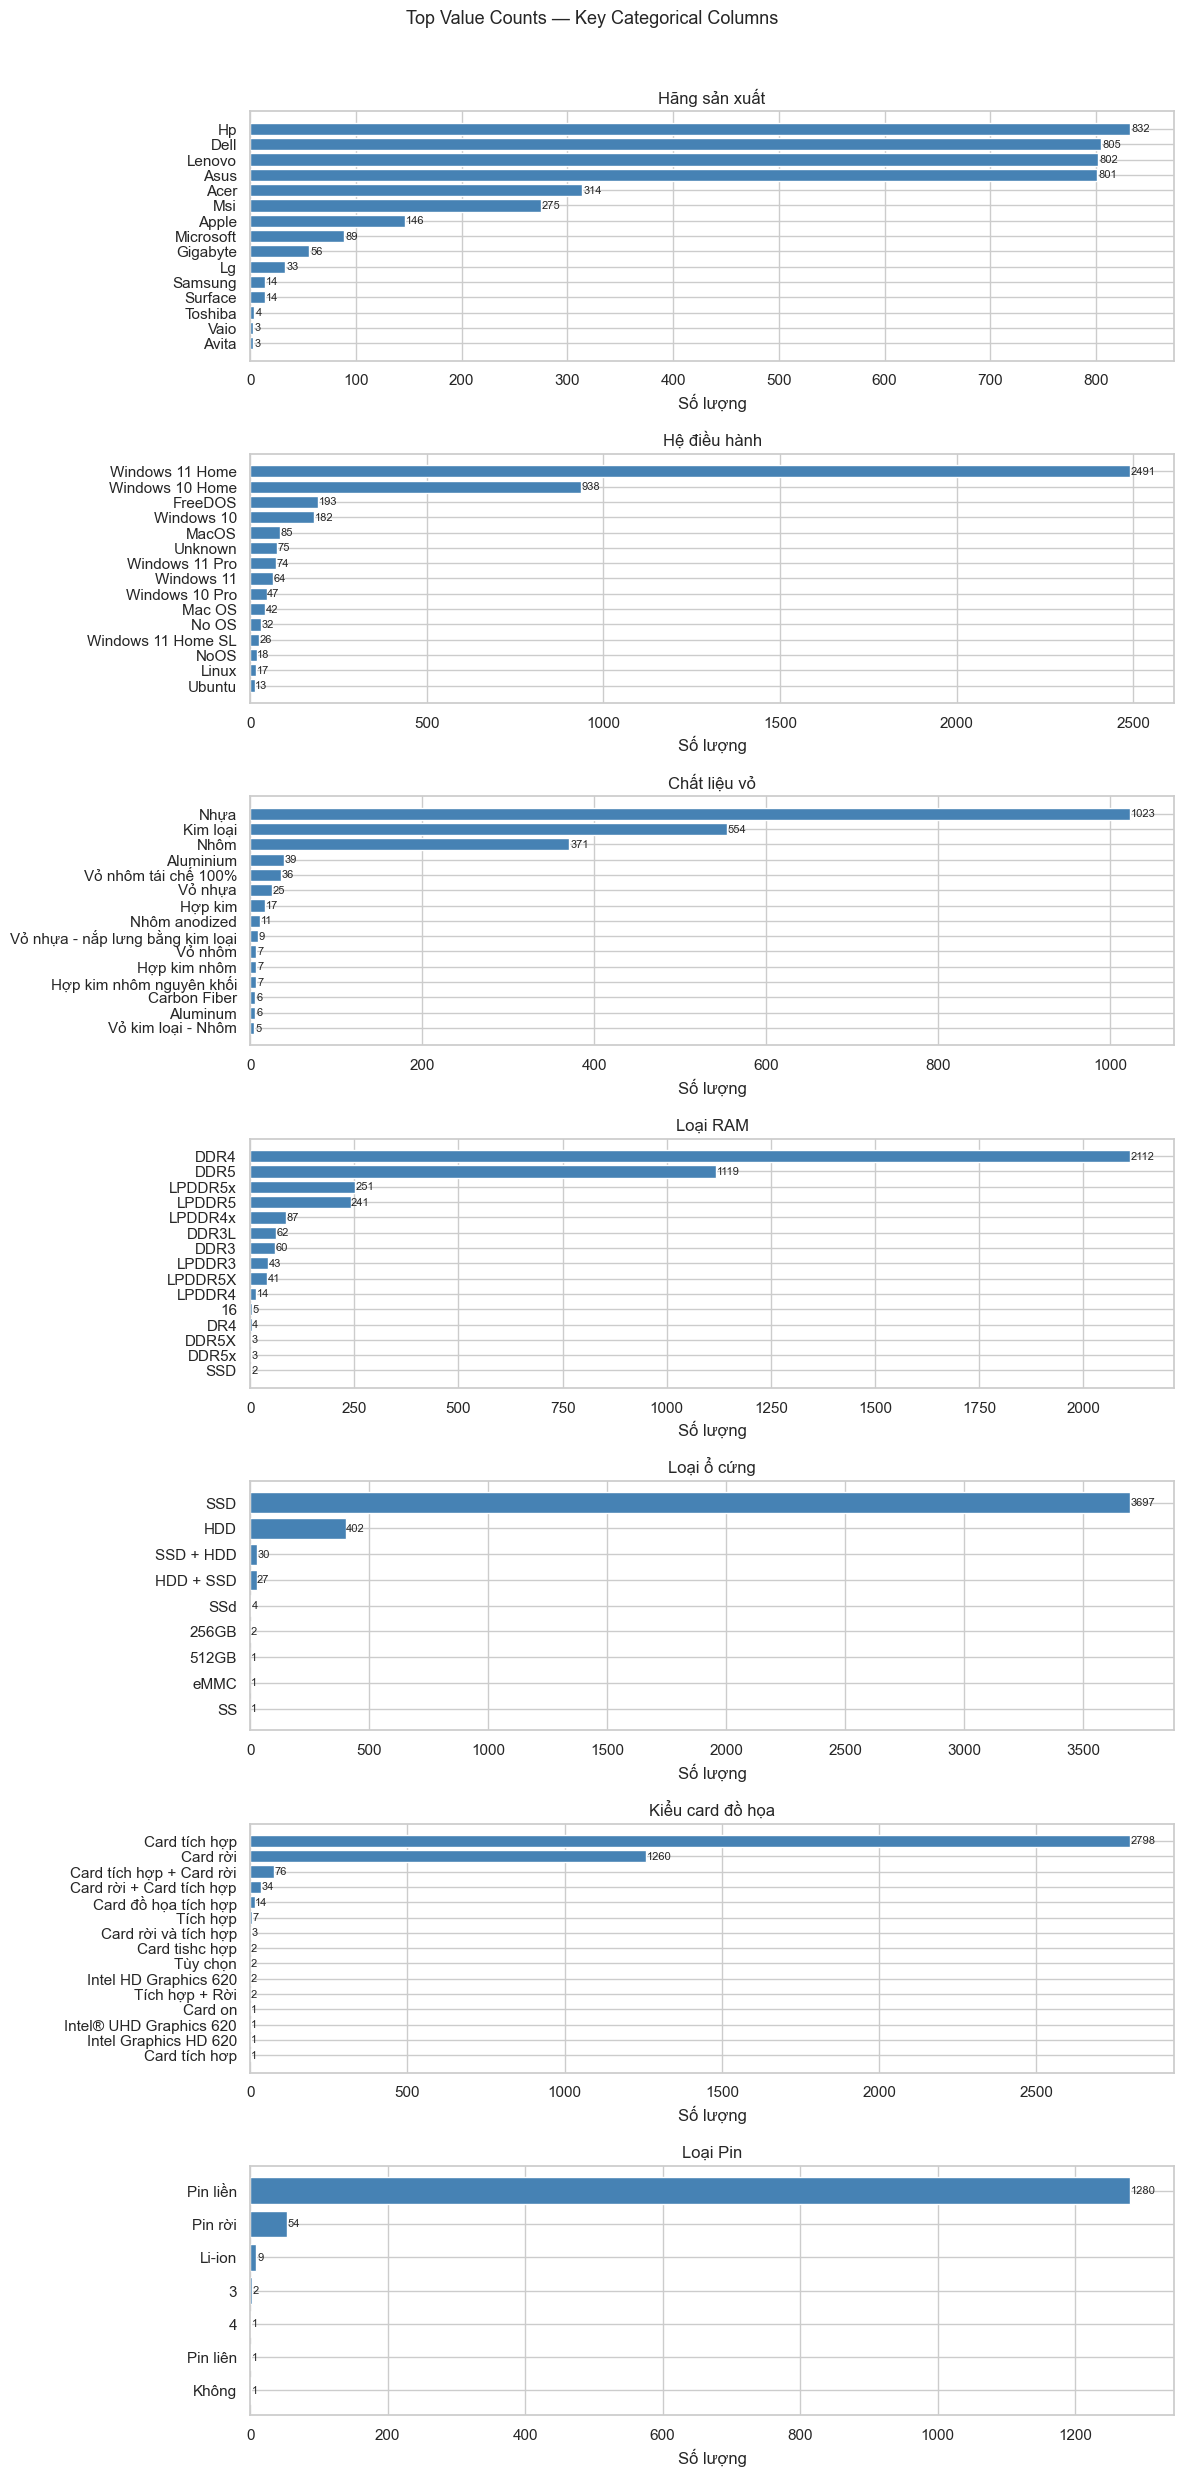

In [21]:
key_cat_cols = [
    'Hãng sản xuất', 'Hệ điều hành', 'Chất liệu vỏ',
    'Loại RAM', 'Loại ổ cứng', 'Kiểu card đồ họa', 'Loại Pin'
]

fig, axes = plt.subplots(len(key_cat_cols), 1, figsize=(12, len(key_cat_cols) * 3.5))

for ax, col in zip(axes, key_cat_cols):
    top = df[col].value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Số lượng')
    for i, v in enumerate(top.values[::-1]):
        ax.text(v + 1, i, str(v), va='center', fontsize=8)

plt.suptitle('Top Value Counts — Key Categorical Columns', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Quick Distribution — Numerical Features
Histogram cho các cột số quan trọng.

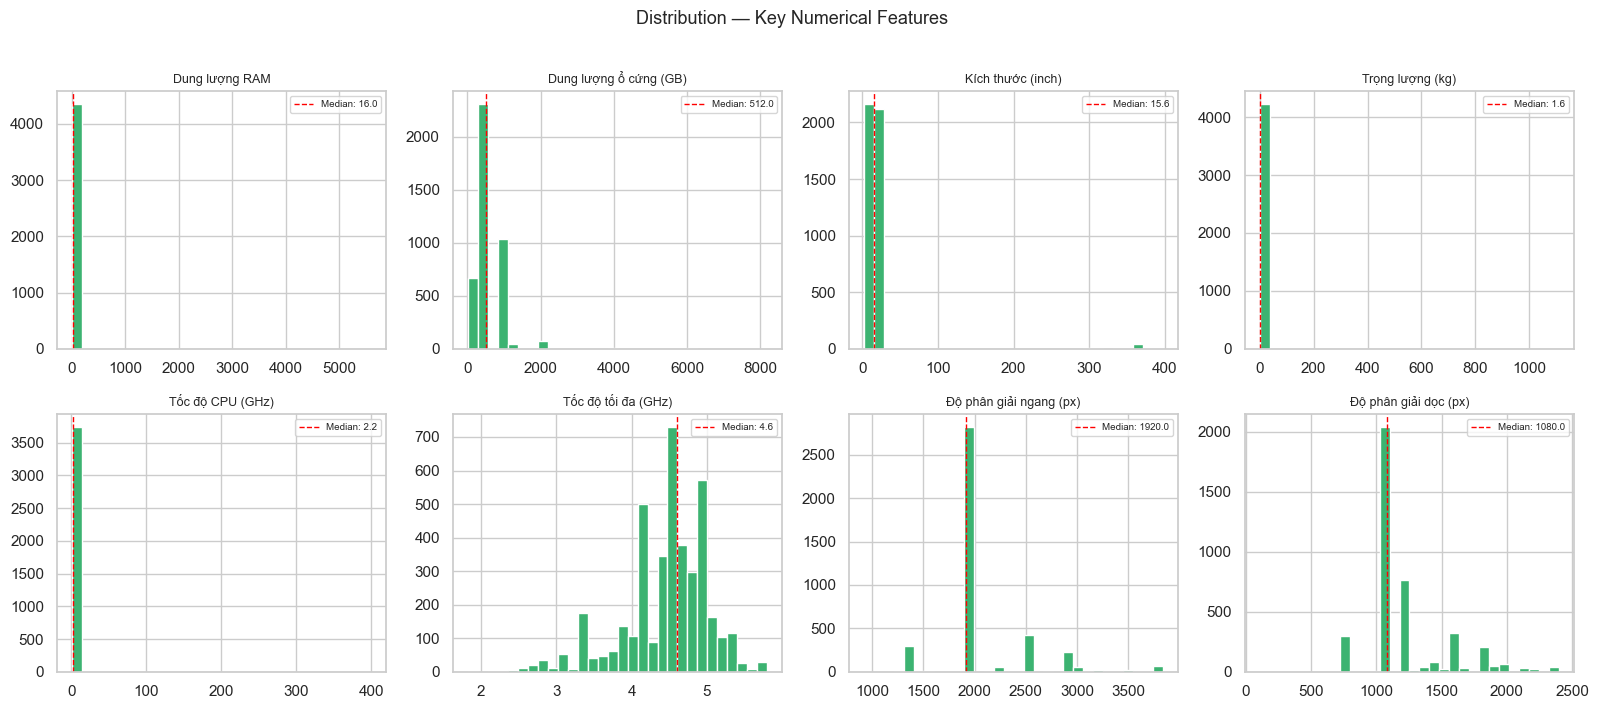

In [22]:
key_num_cols = [
    'Dung lượng RAM', 'Dung lượng ổ cứng (GB)',
    'Kích thước (inch)', 'Trọng lượng (kg)',
    'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)',
    'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)'
]

n = len(key_num_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, key_num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='mediumseagreen', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distribution — Key Numerical Features', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

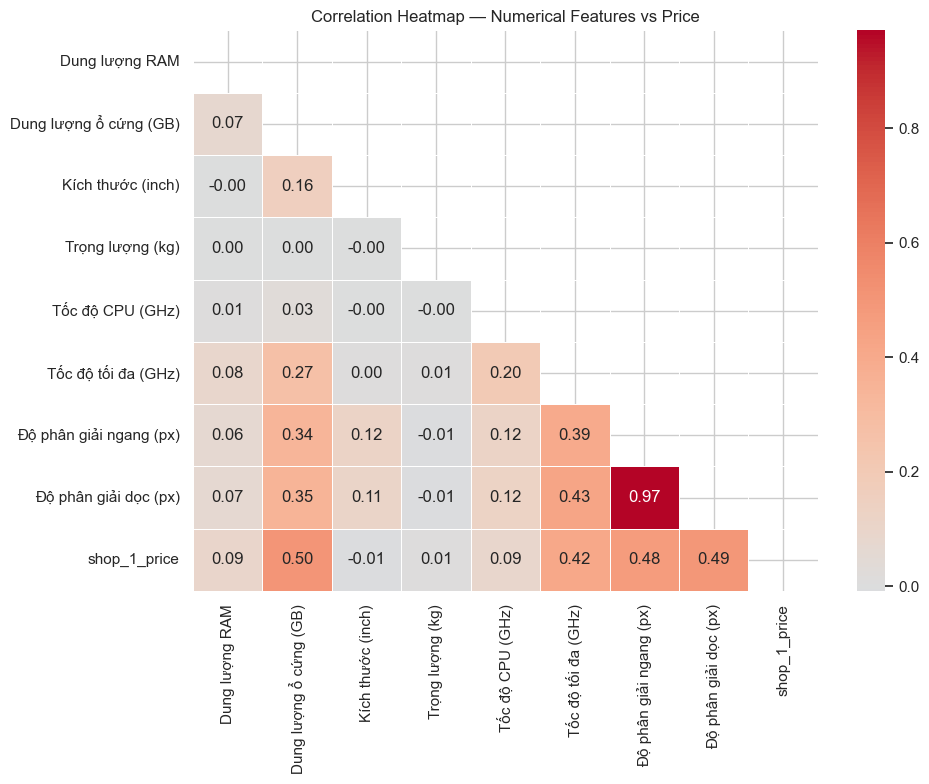

In [23]:
# Tương quan giữa các biến số
corr_cols = key_num_cols + ['shop_1_price']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numerical Features vs Price')
plt.tight_layout()
plt.show()

---
## 11. Summary & Next Steps

### Tổng kết nhanh

| Hạng mục | Quan sát |
|---|---|
| **Kích thước** | 4,384 dòng × 43 cột |
| **Biến mục tiêu** | 3 cột giá (`shop_1/2/3_price`) — phân phối lệch phải, cần xem xét log-transform |
| **Missing values** | Nhiều cột có tỷ lệ missing cao — đặc biệt `shop_3_price`, các cột kích thước vật lý |
| **High-cardinality** | `Công nghệ màn hình`, `Cổng giao tiếp`, `Kết nối không dây` — cần grouping/encoding đặc biệt |
| **Metadata** | `source_url`, `shop_*_link` không dùng cho modeling |
| **Cột cần làm sạch** | `Đồ họa đã làm sạch` còn không nhất quán (RTX 4060 vs RTX4060) |

### Việc cần làm ở notebook tiếp theo

**`01_eda.ipynb`** — Phân tích chuyên sâu:
- Phân tích biến target theo từng feature
- Phân tích outlier
- Phân tích tương quan feature-target

**`02_preprocessing.ipynb`** — Tiền xử lý:
- Xử lý missing values (imputation strategy theo từng cột)
- Chuẩn hoá cột giá, xử lý outlier
- Encoding categorical (label / target / frequency encoding)
- Feature engineering (GPU tier, CPU tier, resolution group...)
- Drop metadata columns